In [1]:
!pip install tokenizers

In [2]:
import os

file_path = "tinyshakespeare.txt"

with open(file_path, "r", encoding="utf-8") as f:
    text = f.read()

print("First 500 characters:\n")
print(text[:500])
print("\nTotal number of characters:", len(text))

First 500 characters:

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor

Total number of characters: 1115394


In [3]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace

# Initialize tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()

# Trainer with vocab size <= 500
trainer = BpeTrainer(
    vocab_size=500,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
)

# Train tokenizer on the Shakespeare corpus
tokenizer.train([file_path], trainer)

# Save tokenizer if needed
tokenizer.save("tinyshakespeare_bpe.json")

# Check vocab size
vocab = tokenizer.get_vocab()
print("Vocabulary size:", len(vocab))

Vocabulary size: 500


In [4]:
sample_text = "To be, or not to be, that is the question."
encoded_sample = tokenizer.encode(sample_text)

print("Original text:")
print(sample_text)

print("\nTokens:")
print(encoded_sample.tokens)

print("\nToken IDs:")
print(encoded_sample.ids)

Original text:
To be, or not to be, that is the question.

Tokens:
['To', 'be', ',', 'or', 'not', 'to', 'be', ',', 'that', 'is', 'the', 'que', 'st', 'ion', '.']

Token IDs:
[187, 95, 8, 73, 113, 82, 95, 8, 118, 74, 72, 435, 79, 230, 10]


In [5]:
encoded = tokenizer.encode(text)
token_ids = encoded.ids

print("Total number of tokens:", len(token_ids))
print("First 50 token IDs:", token_ids[:50])

Total number of tokens: 448129
First 50 token IDs: [407, 17, 93, 49, 66, 75, 12, 396, 283, 116, 300, 101, 110, 424, 46, 138, 131, 8, 395, 81, 365, 10, 15, 80, 12, 33, 154, 252, 8, 365, 10, 407, 17, 93, 49, 66, 75, 12, 318, 158, 135, 58, 86, 316, 92, 44, 145, 131, 82, 277]


In [6]:
import torch
from torch.utils.data import Dataset

class ShakespeareDataset(Dataset):
    def __init__(self, token_ids, seq_len=50, stride=1):
        self.seq_len = seq_len
        self.stride = stride
        self.examples = []

        for i in range(0, len(token_ids) - seq_len, stride):
            chunk = token_ids[i : i + seq_len + 1]
            if len(chunk) == seq_len + 1:
                x = chunk[:-1]   # first N tokens
                y = chunk[1:]    # shifted by one
                self.examples.append((x, y))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        x, y = self.examples[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

In [7]:
split_idx = int(0.8 * len(token_ids))

train_tokens = token_ids[:split_idx]
val_tokens = token_ids[split_idx:]

seq_len = 50

train_dataset = ShakespeareDataset(train_tokens, seq_len=seq_len, stride=1)
val_dataset = ShakespeareDataset(val_tokens, seq_len=seq_len, stride=1)

print("Train token count:", len(train_tokens))
print("Validation token count:", len(val_tokens))
print("Number of train sequences:", len(train_dataset))
print("Number of validation sequences:", len(val_dataset))

Train token count: 358503
Validation token count: 89626
Number of train sequences: 358453
Number of validation sequences: 89576


In [8]:
x, y = train_dataset[0]

print("Input shape:", x.shape)
print("Target shape:", y.shape)

print("\nInput IDs:")
print(x.tolist())

print("\nTarget IDs:")
print(y.tolist())

Input shape: torch.Size([50])
Target shape: torch.Size([50])

Input IDs:
[407, 17, 93, 49, 66, 75, 12, 396, 283, 116, 300, 101, 110, 424, 46, 138, 131, 8, 395, 81, 365, 10, 15, 80, 12, 33, 154, 252, 8, 365, 10, 407, 17, 93, 49, 66, 75, 12, 318, 158, 135, 58, 86, 316, 92, 44, 145, 131, 82, 277]

Target IDs:
[17, 93, 49, 66, 75, 12, 396, 283, 116, 300, 101, 110, 424, 46, 138, 131, 8, 395, 81, 365, 10, 15, 80, 12, 33, 154, 252, 8, 365, 10, 407, 17, 93, 49, 66, 75, 12, 318, 158, 135, 58, 86, 316, 92, 44, 145, 131, 82, 277, 45]


In [9]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch input shape:", xb.shape)   # [batch_size, seq_len]
print("Batch target shape:", yb.shape)  # [batch_size, seq_len]

Batch input shape: torch.Size([32, 50])
Batch target shape: torch.Size([32, 50])


In [10]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [12]:
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # x: (..., dim)
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return self.scale * (x / rms)

In [13]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (B, T, d_model)
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [14]:
class SelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x, return_attention=False):
        # x: (B, T, d_model)
        B, T, C = x.shape

        Q = self.q_proj(x)   # (B, T, C)
        K = self.k_proj(x)   # (B, T, C)
        V = self.v_proj(x)   # (B, T, C)

        # attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(C)   # (B, T, T)

        # causal mask: prevent attending to future tokens
        mask = torch.tril(torch.ones(T, T, device=x.device)).unsqueeze(0)  # (1, T, T)
        scores = scores.masked_fill(mask == 0, float("-inf"))

        attn_weights = torch.softmax(scores, dim=-1)   # (B, T, T)
        attn_output = torch.matmul(attn_weights, V)    # (B, T, C)

        out = self.out_proj(attn_output)               # (B, T, C)

        if return_attention:
            return out, attn_weights
        return out

In [15]:
class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d_model)
        )

    def forward(self, x):
        return self.net(x)

In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, ff_hidden_dim):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = SelfAttention(d_model)

        self.norm2 = RMSNorm(d_model)
        self.ffn = FeedForward(d_model, ff_hidden_dim)

        self.dropout = nn.Dropout(0.1)

    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn_weights = self.attn(self.norm1(x), return_attention=True)
            x = x + self.dropout(self.attn(self.norm1(x)))
            x = x + self.dropout(self.ffn(self.norm2(x)))
            return x, attn_weights
        else:
            x = x + self.attn(self.norm1(x))
            x = x + self.ffn(self.norm2(x))
            return x

In [17]:
class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=128, max_len=512, ff_hidden_dim=256, num_layers=1):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len=max_len)

        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, ff_hidden_dim) for _ in range(num_layers)
        ])

        self.final_norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, return_attention=False):
        # x: (B, T)
        x = self.token_embedding(x)   # (B, T, d_model)
        x = self.pos_encoding(x)      # (B, T, d_model)
        x = self.dropout(x)

        attention_maps = []

        for block in self.blocks:
            if return_attention:
                x, attn = block(x, return_attention=True)
                attention_maps.append(attn)
            else:
                x = block(x)

        x = self.final_norm(x)
        logits = self.lm_head(x)      # (B, T, vocab_size)

        if return_attention:
            return logits, attention_maps
        return logits

In [18]:
vocab_size = len(tokenizer.get_vocab())
seq_len = 50

d_model = 128
ff_hidden_dim = 256
num_layers = 1
learning_rate = 1e-4
num_epochs = 30

model = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=d_model,
    max_len=seq_len,
    ff_hidden_dim=ff_hidden_dim,
    num_layers=num_layers
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

print(model)

TinyTransformerLM(
  (token_embedding): Embedding(500, 128)
  (pos_encoding): PositionalEncoding()
  (blocks): ModuleList(
    (0): TransformerBlock(
      (norm1): RMSNorm()
      (attn): SelfAttention(
        (q_proj): Linear(in_features=128, out_features=128, bias=True)
        (k_proj): Linear(in_features=128, out_features=128, bias=True)
        (v_proj): Linear(in_features=128, out_features=128, bias=True)
        (out_proj): Linear(in_features=128, out_features=128, bias=True)
      )
      (norm2): RMSNorm()
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=256, bias=True)
          (1): ReLU()
          (2): Linear(in_features=256, out_features=128, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
  )
  (final_norm): RMSNorm()
  (lm_head): Linear(in_features=128, out_features=500, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)


In [19]:
def compute_loss(logits, targets):
    # logits: (B, T, V)
    # targets: (B, T)
    B, T, V = logits.shape
    logits = logits.view(B * T, V)
    targets = targets.view(B * T)
    return criterion(logits, targets)

In [20]:
def train_one_epoch(model, dataloader, optimizer):
    model.train()
    total_loss = 0.0

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        logits = model(xb)
        loss = compute_loss(logits, yb)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [21]:
@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0

    for xb, yb in dataloader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = compute_loss(logits, yb)

        total_loss += loss.item()

    return total_loss / len(dataloader)

In [22]:
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = evaluate(model, val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

Epoch 1/30 | Train Loss: 4.2465 | Val Loss: 4.2788
Epoch 2/30 | Train Loss: 3.7568 | Val Loss: 4.1862
Epoch 3/30 | Train Loss: 3.6134 | Val Loss: 4.1421
Epoch 4/30 | Train Loss: 3.5309 | Val Loss: 4.1225
Epoch 5/30 | Train Loss: 3.4754 | Val Loss: 4.1142
Epoch 6/30 | Train Loss: 3.4331 | Val Loss: 4.0945
Epoch 7/30 | Train Loss: 3.4001 | Val Loss: 4.0882
Epoch 8/30 | Train Loss: 3.3731 | Val Loss: 4.0929
Epoch 9/30 | Train Loss: 3.3506 | Val Loss: 4.0840
Epoch 10/30 | Train Loss: 3.3310 | Val Loss: 4.0827
Epoch 11/30 | Train Loss: 3.3142 | Val Loss: 4.0807
Epoch 12/30 | Train Loss: 3.2992 | Val Loss: 4.0832
Epoch 13/30 | Train Loss: 3.2859 | Val Loss: 4.0832
Epoch 14/30 | Train Loss: 3.2736 | Val Loss: 4.0800
Epoch 15/30 | Train Loss: 3.2627 | Val Loss: 4.0798
Epoch 16/30 | Train Loss: 3.2530 | Val Loss: 4.0789
Epoch 17/30 | Train Loss: 3.2436 | Val Loss: 4.0764
Epoch 18/30 | Train Loss: 3.2353 | Val Loss: 4.0742
Epoch 19/30 | Train Loss: 3.2276 | Val Loss: 4.0785
Epoch 20/30 | Train L

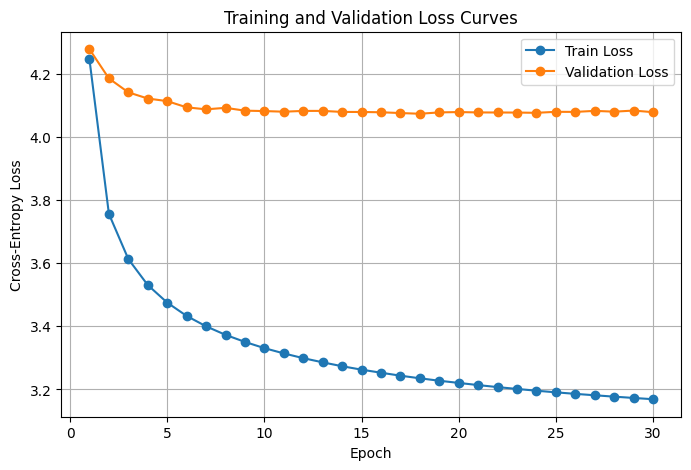

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o', label="Train Loss")
plt.plot(range(1, len(val_losses) + 1), val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import math
val_loss = evaluate(model, val_loader)
val_ppl = math.exp(val_loss)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Perplexity (PPL): {val_ppl:.4f}")

Validation Loss: 4.0792
Validation Perplexity (PPL): 59.0983


In [26]:
x = x.to(device)   # ← 加这一行
logits, attention_maps = model(x, return_attention=True)

In [27]:
xb, yb = next(iter(val_loader))
sample_x = xb[:1].to(device)   # shape: (1, seq_len)
model.eval()
with torch.no_grad():
    logits, attention_maps = model(sample_x, return_attention=True)
attn = attention_maps[0][0].cpu()   # shape: (seq_len, seq_len)
print(attn.shape)
id_to_token = {idx: tok for tok, idx in tokenizer.get_vocab().items()}
tokens = [id_to_token[i.item()] for i in sample_x[0].cpu()]
print(tokens[:20])

torch.Size([50, 50])
['r', 'ant', 'to', 'him', '.', 'As', 'for', 'you', ',', 'S', 'ay', 'what', 'you', 'can', ',', 'my', 'f', 'al', 'se', 'o']


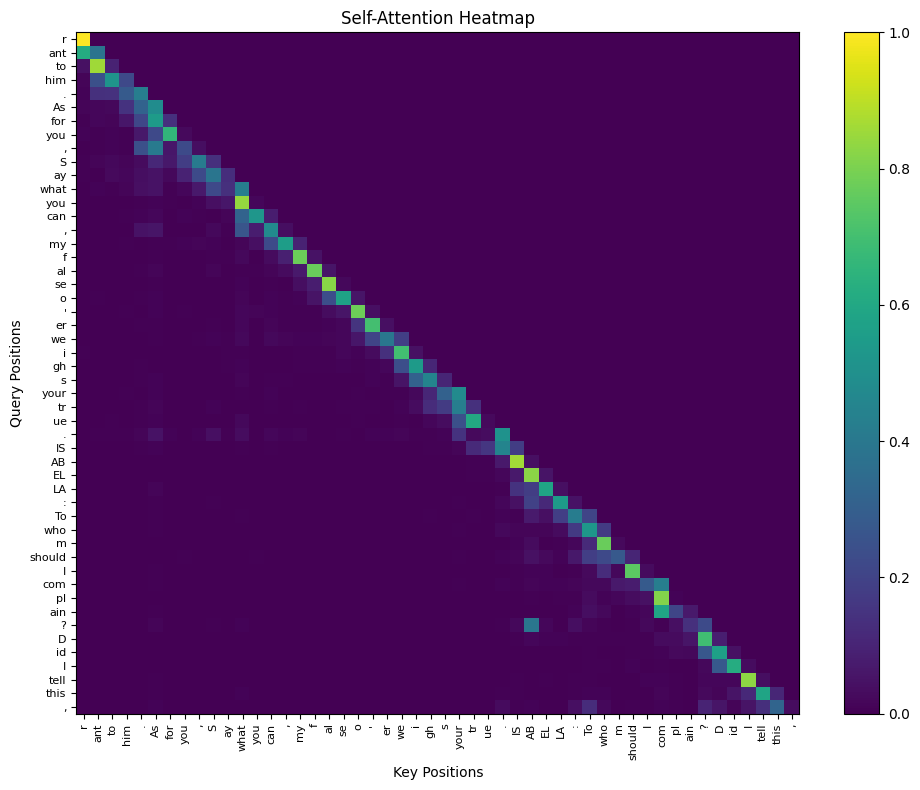

In [28]:
plt.figure(figsize=(10, 8))
plt.imshow(attn, aspect='auto')
plt.colorbar()
plt.title("Self-Attention Heatmap")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")

tick_positions = list(range(len(tokens)))
plt.xticks(tick_positions, tokens, rotation=90, fontsize=8)
plt.yticks(tick_positions, tokens, fontsize=8)

plt.tight_layout()
plt.show()

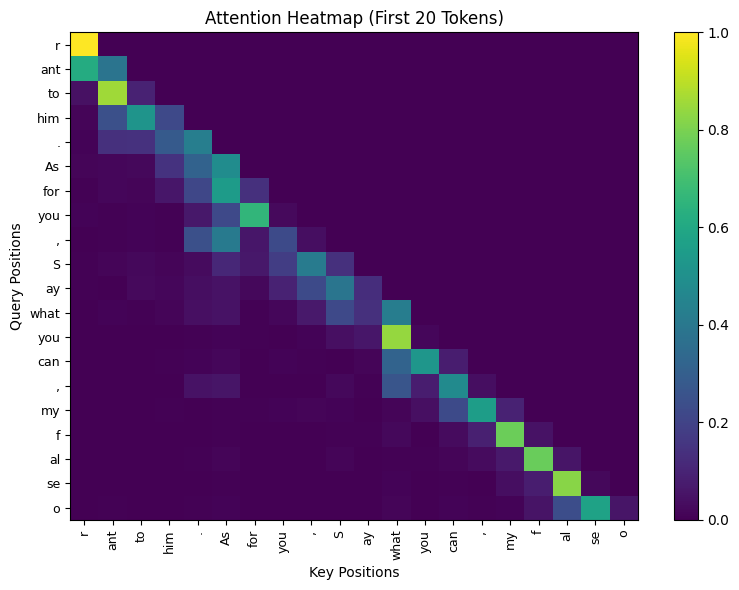

In [29]:
n = 20
attn_small = attn[:n, :n]
tokens_small = tokens[:n]

plt.figure(figsize=(8, 6))
plt.imshow(attn_small, aspect='auto')
plt.colorbar()
plt.title("Attention Heatmap (First 20 Tokens)")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.xticks(range(n), tokens_small, rotation=90, fontsize=9)
plt.yticks(range(n), tokens_small, fontsize=9)
plt.tight_layout()
plt.show()

In [43]:
@torch.no_grad()
def generate_text(model, tokenizer, prompt, max_new_tokens=50, seq_len=50):
    model.eval()

    encoded = tokenizer.encode(prompt)
    input_ids = encoded.ids

    x = torch.tensor(input_ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        x_cond = x[:, -seq_len:]   # keep last seq_len tokens
        logits = model(x_cond)
        next_token_logits = logits[:, -1, :]
        probs = torch.softmax(next_token_logits, dim=-1)

        next_token = torch.argmax(probs, dim=-1, keepdim=True)
        x = torch.cat([x, next_token], dim=1)

    return tokenizer.decode(x[0].tolist())
sample_output = generate_text(model, tokenizer, prompt="To be or not", max_new_tokens=50)
print(sample_output)

To be or not the c rown , and f o llow ers . I ' ll be g in s , and I ' ll not be ar the king , And I , in de ed , and I ' ll not be ar the king , And I ' ll not


In [36]:
print(generate_text(model, tokenizer, prompt="Juliet:", max_new_tokens=60, seq_len=50))

J u li et : if I make such qu i ck ly not such an one with th o se my d am I In ra w ar , and from the pre ci ous n or hath but at ch er To time s to - mor row s p al a ce . P ER D I T A : Come ,


Epoch 1/3 | Train Loss: 4.2388 | Val Loss: 4.2626
Epoch 2/3 | Train Loss: 3.7604 | Val Loss: 4.1691
Epoch 3/3 | Train Loss: 3.6156 | Val Loss: 4.1316


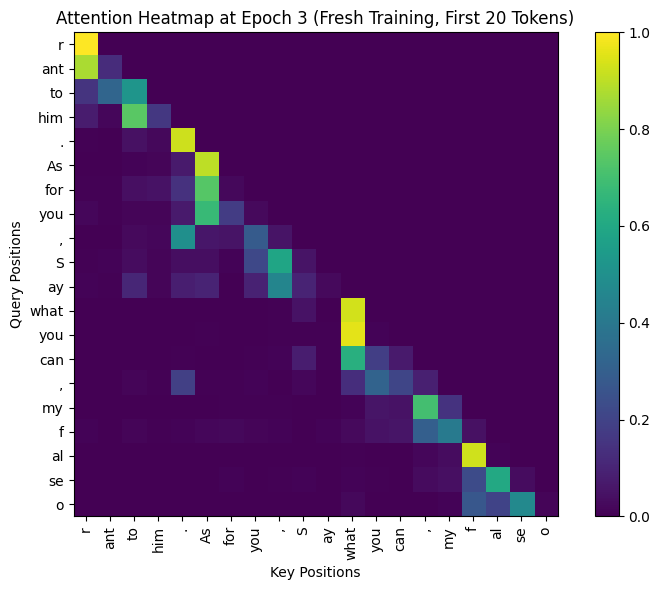

In [42]:
import torch
import matplotlib.pyplot as plt

# ===== 1. 从头初始化模型 =====
fresh_model = TinyTransformerLM(
    vocab_size=vocab_size,
    d_model=d_model,
    max_len=seq_len,
    ff_hidden_dim=ff_hidden_dim,
    num_layers=num_layers
).to(device)

fresh_optimizer1 = torch.optim.AdamW(
    fresh_model.parameters(), lr=1e-4, weight_decay=0.01
)

# ===== 2. 从头训练 3 个 epoch =====
for epoch in range(3):
    train_loss = train_one_epoch(fresh_model, train_loader, fresh_optimizer1)
    val_loss = evaluate(fresh_model, val_loader)
    print(f"Epoch {epoch+1}/3 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

# ===== 3. 取一个 validation batch =====
fresh_model.eval()
xb, yb = next(iter(val_loader))
xb = xb.to(device)

# ===== 4. 拿 attention =====
with torch.no_grad():
    logits, attention_maps = fresh_model(xb, return_attention=True)

attn = attention_maps[0][0].detach().cpu().numpy()  # 第一层，第一个样本

# ===== 5. 可视化前20个 token =====
tokens = xb[0].detach().cpu().tolist()
token_labels = tokenizer.decode(tokens[:20]).split()

# 👉 更稳一点（防止 BPE split 不对齐）
if len(token_labels) != 20:
    token_labels = [str(t) for t in tokens[:20]]

plt.figure(figsize=(8, 6))
plt.imshow(attn[:20, :20], cmap="viridis")
plt.colorbar()

# ✅ 改这里
plt.title("Attention Heatmap at Epoch 3 (Fresh Training, First 20 Tokens)")

plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.xticks(range(20), token_labels, rotation=90)
plt.yticks(range(20), token_labels)
plt.tight_layout()
plt.show()